In [26]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [27]:
# !wget https://archive.ics.uci.edu/static/public/20/census+income.zip

In [28]:
# !unzip census+income.zip

In [29]:
!pip install openml

In [30]:
import openml as oml
dataset = oml.datasets.get_dataset(44090)
df, _, _, _ = dataset.get_data()

In [31]:
import pandas as pd

# df = pd.read_csv('adult.data', names = ['age','workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'])
print(len(df))
df

20634


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,2.1827,26,4.521429,0.921429,305.0,2.178571,40.05,-122.10,False
1,3.0755,32,4.623068,0.983353,3868.0,4.599287,32.77,-117.06,False
2,1.8235,40,4.701149,1.126437,928.0,3.555556,37.75,-122.16,False
3,1.4625,37,4.247845,1.105603,1673.0,3.605603,33.99,-118.28,False
4,1.9063,13,3.453125,0.984375,286.0,4.468750,33.97,-118.16,False
...,...,...,...,...,...,...,...,...,...
20629,4.3487,29,5.930712,1.026217,1554.0,2.910112,38.65,-121.84,True
20630,5.6790,20,6.401274,1.070064,457.0,2.910828,38.56,-122.05,True
20631,1.9327,10,5.789474,1.078947,898.0,3.938596,38.57,-121.92,True
20632,3.7500,38,5.275229,0.981651,259.0,2.376147,38.72,-121.90,True


In [32]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'price'],
      dtype='object')

In [33]:
import numpy as np
import torch

DROP_P = 0.2

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'
    
    text = "".join([f"I have information about a district in California. ",
            f"Its median income is {x['MedInc']}. ",
            f"Its housing median age is {x['HouseAge']}. ",
            f"Its average rooms number is {x['AveRooms']}. ",
            f"Its average bedrooms number is {x['AveBedrms']}. ",
            f"Its total population is {x['Population']}. ",
            f"Its average number of people under the same roof is {x['AveOccup']}. ",
            f"Its latitude {x['Latitude']}. ",
            f"Its longitude {x['Longitude']}."])

    
    return text

concatenate_text(df.iloc[0])

'I have information about a district in California. Its median income is 2.1827. Its housing median age is 26. Its average rooms number is 4.521428571428571. Its average bedrooms number is 0.9214285714285714. Its total population is [UNK]. Its average number of people under the same roof is [UNK]. Its latitude [UNK]. Its longitude -122.1.'

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('price', axis =1),
                                                    df['price'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({True:1, False:0})
y_test = y_test.replace({True:1, False:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

<ipython-input-34-dd20caba4982>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({True:1, False:0})
<ipython-input-34-dd20caba4982>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({True:1, False:0})


In [35]:
X_train['text'].iloc[0]

'I have information about a district in California. Its median income is 5.5205. Its housing median age is [UNK]. Its average rooms number is 7.225531914893617. Its average bedrooms number is 1.0340425531914894. Its total population is 1974.0. Its average number of people under the same roof is [UNK]. Its latitude [UNK]. Its longitude -121.25.'

In [36]:
len(X_train)

16507

In [37]:
!pip install evaluate

In [38]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/16507 [00:00<?, ? examples/s]

Map:   0%|          | 0/4127 [00:00<?, ? examples/s]

Map:   0%|          | 0/16507 [00:00<?, ? examples/s]

Map:   0%|          | 0/4127 [00:00<?, ? examples/s]

In [39]:
tokenized_train_dataset[0].keys()

dict_keys(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [40]:
tokenized_train_dataset[0]['text']

'I have information about a district in California. Its median income is 5.5205. Its housing median age is [UNK]. Its average rooms number is 7.225531914893617. Its average bedrooms number is 1.0340425531914894. Its total population is 1974.0. Its average number of people under the same roof is [UNK]. Its latitude [UNK]. Its longitude -121.25.'

In [41]:
tokenized_train_dataset[0]['label']

1

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.709400,0.699394,0.505045
2,0.694700,0.693584,0.518652
3,0.709200,0.703951,0.522079
4,0.696300,0.693829,0.530779
5,0.696000,0.695194,0.541562
6,0.692200,0.692709,0.551848
7,0.692700,0.692379,0.558351
8,0.694100,0.692921,0.557767
9,0.692700,0.692332,0.554520
10,0.691600,0.692605,0.553615


{'eval_loss': 0.6926050186157227, 'eval_roc_auc': 0.5536151114618268, 'eval_runtime': 15.4347, 'eval_samples_per_second': 267.384, 'eval_steps_per_second': 4.211, 'epoch': 10.0}
test f1 0.6607260726072607
test precision 0.4998751560549313
test recall 0.9742092457420924
test accuracy 0.4998751560549313
test roc_auc 0.5274704318499939



train f1 0.6634290888138941
train precision 0.5026191070092292
train recall 0.9755507141128056
train accuracy 0.5045738171684739
train roc_auc 0.5367574870240379


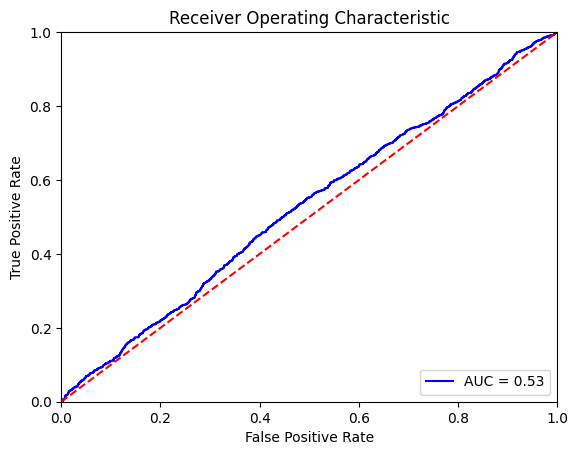

In [42]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.455500,0.444775,0.879134
2,0.396200,0.415018,0.902480
3,0.395600,0.371365,0.916418
4,0.374500,0.360851,0.921467
5,0.337400,0.350812,0.926725
6,0.314000,0.354581,0.927312
7,0.273500,0.351609,0.929297
8,0.332300,0.357490,0.928310
9,0.300700,0.358012,0.929049
10,0.242700,0.358627,0.929438


{'eval_loss': 0.35862720012664795, 'eval_roc_auc': 0.929438275606159, 'eval_runtime': 15.4495, 'eval_samples_per_second': 267.129, 'eval_steps_per_second': 4.207, 'epoch': 10.0}
test f1 0.8478207937667397
test precision 0.8484405458089669
test recall 0.8472019464720195
test accuracy 0.8484405458089669
test roc_auc 0.928126614622965



train f1 0.8897081041880703
train precision 0.8884731442365721
train recall 0.8909465020576132
train accuracy 0.8894408432786091
train roc_auc 0.9587158520843819


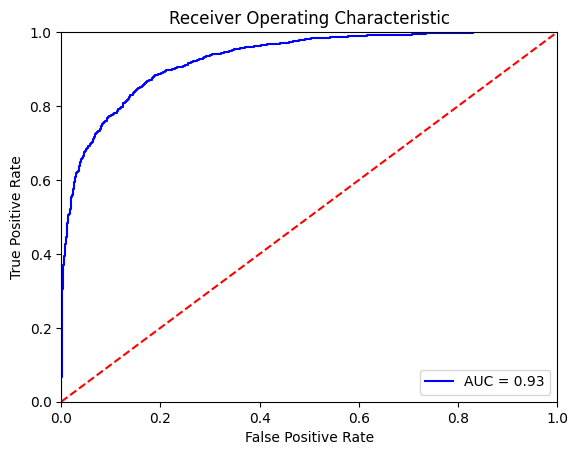

In [43]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

<ipython-input-44-94ccfc733210>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({True:1, False:0})
<ipython-input-44-94ccfc733210>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({True:1, False:0})


Map:   0%|          | 0/16507 [00:00<?, ? examples/s]

Map:   0%|          | 0/4127 [00:00<?, ? examples/s]

Map:   0%|          | 0/16507 [00:00<?, ? examples/s]

Map:   0%|          | 0/4127 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.702900,0.712658,0.497346
2,0.697600,0.713883,0.515743
3,0.704800,0.698473,0.518387
4,0.695700,0.693900,0.509693
5,0.697400,0.695011,0.520604
6,0.691300,0.692778,0.525753
7,0.692300,0.692622,0.533896
8,0.693600,0.693907,0.533125
9,0.693700,0.692633,0.528663
10,0.691900,0.692679,0.531489


{'eval_loss': 0.6926794052124023, 'eval_roc_auc': 0.5314886706310064, 'eval_runtime': 15.437, 'eval_samples_per_second': 267.344, 'eval_steps_per_second': 4.211, 'epoch': 10.0}
test f1 0.6191198786039454
test precision 0.507304942493006
test recall 0.7941605839416058
test accuracy 0.507304942493006
test roc_auc 0.5363563772322897



train f1 0.6218082088140723
train precision 0.5102436753065343
train recall 0.7958121520213024
train accuracy 0.5154782819409948
train roc_auc 0.5297411897999698


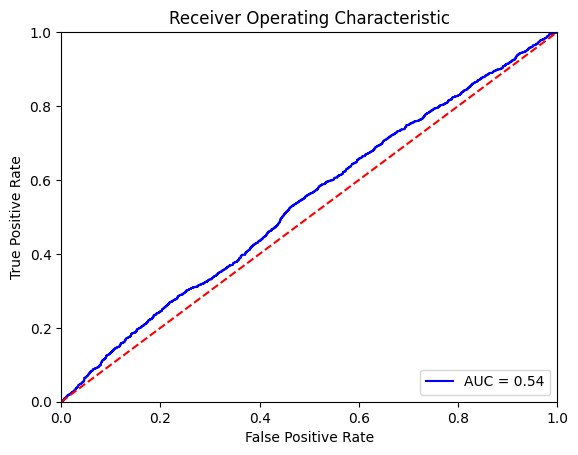

In [44]:
DROP_P = 0.5

X_train, X_test, y_train, y_test = train_test_split(df.drop('price', axis =1),
                                                    df['price'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({True:1, False:0})
y_test = y_test.replace({True:1, False:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.534700,0.542410,0.799273
2,0.508100,0.537208,0.825481
3,0.476800,0.500450,0.833646
4,0.487700,0.506416,0.838266
5,0.449100,0.498948,0.841810
6,0.423900,0.495485,0.846596
7,0.361300,0.506803,0.846218
8,0.440300,0.496199,0.848785
9,0.435400,0.490037,0.850237
10,0.444100,0.496996,0.849822


{'eval_loss': 0.4969959557056427, 'eval_roc_auc': 0.8498220979060396, 'eval_runtime': 15.3984, 'eval_samples_per_second': 268.015, 'eval_steps_per_second': 4.221, 'epoch': 10.0}
test f1 0.7553294573643411
test precision 0.7520501688374337
test recall 0.7586374695863747
test accuracy 0.7520501688374337
test roc_auc 0.8472478604777874



train f1 0.8135224871717476
train precision 0.8115139106347103
train recall 0.8155410312273057
train accuracy 0.8128672684315745
train roc_auc 0.9019008608167416


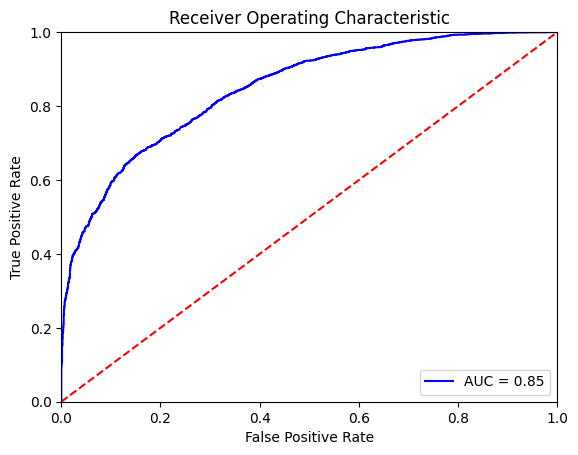

In [45]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

<ipython-input-46-151ea67246b5>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({True:1, False:0})
<ipython-input-46-151ea67246b5>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({True:1, False:0})


Map:   0%|          | 0/16507 [00:00<?, ? examples/s]

Map:   0%|          | 0/4127 [00:00<?, ? examples/s]

Map:   0%|          | 0/16507 [00:00<?, ? examples/s]

Map:   0%|          | 0/4127 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.714000,0.729346,0.493739
2,0.714800,0.775497,0.492460
3,0.707100,0.694908,0.503045
4,0.697500,0.695793,0.502993
5,0.696800,0.695751,0.503290
6,0.691500,0.693481,0.501131
7,0.694900,0.693240,0.506860
8,0.694700,0.694517,0.508973
9,0.693700,0.693201,0.511546
10,0.694200,0.693291,0.513487


{'eval_loss': 0.6932913661003113, 'eval_roc_auc': 0.5134872098375748, 'eval_runtime': 15.4079, 'eval_samples_per_second': 267.85, 'eval_steps_per_second': 4.219, 'epoch': 10.0}
test f1 0.6648333872533161
test precision 0.49794039253695177
test recall 1.0
test accuracy 0.49794039253695177
test roc_auc 0.5110990944020142



train f1 0.667124227865477
train precision 0.5005149330587023
train recall 1.0
train accuracy 0.5005149330587023
train roc_auc 0.506354481688909


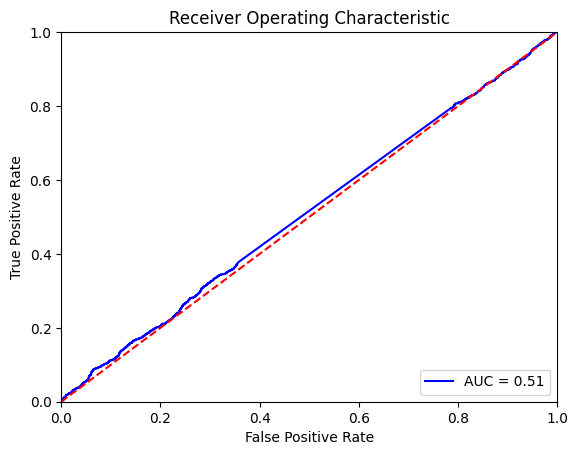

In [46]:
DROP_P = 0.9

X_train, X_test, y_train, y_test = train_test_split(df.drop('price', axis =1),
                                                    df['price'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({True:1, False:0})
y_test = y_test.replace({True:1, False:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.693700,0.692871,0.516025
2,0.673400,0.679413,0.555572
3,0.675600,0.672125,0.591021
4,0.652700,0.663379,0.609077
5,0.645200,0.660775,0.611038
6,0.659200,0.656378,0.621396
7,0.634900,0.657989,0.627387
8,0.647400,0.657375,0.616655
9,0.621700,0.658555,0.619842
10,0.633400,0.660109,0.621521


{'eval_loss': 0.6601090431213379, 'eval_roc_auc': 0.6215208691486065, 'eval_runtime': 15.4697, 'eval_samples_per_second': 266.78, 'eval_steps_per_second': 4.202, 'epoch': 10.0}
test f1 0.4619119878603946
test precision 0.6137096774193549
test recall 0.37031630170316304
test accuracy 0.6137096774193549
test roc_auc 0.6231829326719837



train f1 0.49217855780236563
train precision 0.6659095601899649
train recall 0.39034132171387076
train accuracy 0.596837705215969
train roc_auc 0.6636689357443073


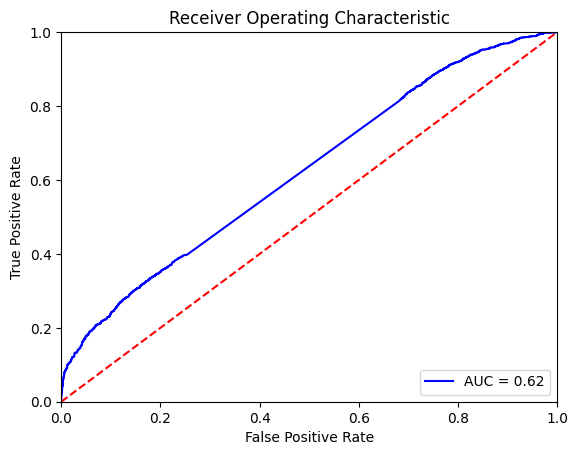

In [47]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()